<a href="https://colab.research.google.com/github/npribadi-lab/Final-lab/blob/main/VGG16_Gamma_0%2C8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense, Activation,Dropout,Conv2D, MaxPooling2D,BatchNormalization, Flatten,Input
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model, Sequential
from keras.callbacks import ModelCheckpoint
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import os
import seaborn as sns
sns.set_style('darkgrid')
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display, HTML
import pickle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==================================================
# 1. KONFIGURASI FOLDER (sesuaikan dengan path Anda)
# ==================================================
sdir = '/content/drive/MyDrive/SkripsiOASYS/dataset gamma correction/benar 0,8/FIX 0,8/TrainVal'   # folder berisi TO dan no_TO (371 gambar)
test_dir = '/content/drive/MyDrive/SkripsiOASYS/dataset gamma correction/benar 0,8/FIX 0,8/Test'  # folder berisi TO dan no_TO (41 gambar)

In [ ]:
# ==================================================
# 2. MEMBACA DATA TRAIN+VALID DARI sdir
# ==================================================
filepaths = []
labels = []
classlist = os.listdir(sdir)
for klass in classlist:
    classpath = os.path.join(sdir, klass)
    if os.path.isdir(classpath):
        flist = os.listdir(classpath)
        for f in flist:
            fpath = os.path.join(classpath, f)
            filepaths.append(fpath)
            labels.append(klass)

Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis=1)
print("Data train+valid (total 371 gambar):")
print(df.head())
print(df['labels'].value_counts())

Data train+valid (total 371 gambar):
                                           filepaths labels
0  /content/drive/MyDrive/SkripsiOASYS/dataset ga...     TO
1  /content/drive/MyDrive/SkripsiOASYS/dataset ga...     TO
2  /content/drive/MyDrive/SkripsiOASYS/dataset ga...     TO
3  /content/drive/MyDrive/SkripsiOASYS/dataset ga...     TO
4  /content/drive/MyDrive/SkripsiOASYS/dataset ga...     TO
labels
TO       252
no_TO    119
Name: count, dtype: int64


In [ ]:
# ==================================================
# 3. BAGI MENJADI TRAIN (330) DAN VALID (41)
# ==================================================
train_df, valid_df = train_test_split(df, train_size=330, stratify=df['labels'], random_state=123)
print(f'\ntrain_df length: {len(train_df)}')
print(f'valid_df length: {len(valid_df)}')
print(f'Total: {len(train_df)+len(valid_df)}')


train_df length: 330
valid_df length: 41
Total: 371


In [ ]:
# ==================================================
# 4. PARAMETER GENERATOR (dengan urutan kelas no_TO=0, TO=1)
# ==================================================
height, width = 224, 224
batch_size = 64
img_size = (height, width)

test_batch_size = 41
test_steps = int(41 / test_batch_size)

# Generator training
train_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    train_df, x_col='filepaths', y_col='labels', target_size=img_size,
    class_mode='categorical', color_mode='rgb', shuffle=True, batch_size=batch_size,
    classes=['no_TO', 'TO']
)

# Generator validasi
valid_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    valid_df, x_col='filepaths', y_col='labels', target_size=img_size,
    class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=batch_size,
    classes=['no_TO', 'TO']
)

# Generator test
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir, target_size=img_size, class_mode='categorical',
    color_mode='rgb', shuffle=False, batch_size=test_batch_size,
    classes=['no_TO', 'TO']
)

classes = list(train_gen.class_indices.keys())
print("\nKelas:", classes)   # ['no_TO', 'TO']
print(f"Jumlah kelas: {len(classes)}")

Found 330 validated image filenames belonging to 2 classes.
Found 41 validated image filenames belonging to 2 classes.
Found 41 images belonging to 2 classes.

Kelas: ['no_TO', 'TO']
Jumlah kelas: 2


In [ ]:
# ==================================================
# 5. ARSITEKTUR MODEL VGG16 (sesuai permintaan)
# ==================================================
base_model = tf.keras.applications.VGG16(include_top=False, weights="imagenet", input_tensor=Input(shape=(224,224,3)))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
base_model.trainable = False   # freeze seluruh base model

In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 119,554,050 (456.06 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# ==================================================
# 6. TRAINING DAN LANGSUNG SIMPAN MODEL + HISTORY
# ==================================================
epochs = 25
history = model.fit(x=train_gen, epochs=epochs, validation_data=valid_gen, verbose=1)

# Simpan model setelah training selesai
model_save_path = '/content/drive/MyDrive/SkripsiOASYS/dataset gamma correction/benar 0,8/FIX 0,8/modelfix_gama08.h5'  # ganti sesuai keinginan
model.save(model_save_path)
print(f"\nModel telah disimpan di {model_save_path}")

# Simpan history ke file pickle
history_save_path = '/content/drive/MyDrive/SkripsiOASYS/dataset gamma correction/benar 0,8/FIX 0,8/historyfix_gama08.pkl'
with open(history_save_path, 'wb') as f:
    pickle.dump(history.history, f)
print(f"History disimpan di {history_save_path}")

Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 333s 52s/step - accuracy: 0.5333 - loss: 23.5129 - val_accuracy: 0.6829 - val_loss: 4.9068
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 302s 50s/step - accuracy: 0.6818 - loss: 2.3355 - val_accuracy: 0.6829 - val_loss: 1.7059
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 297s 49s/step - accuracy: 0.7242 - loss: 0.8317 - val_accuracy: 0.7561 - val_loss: 0.5419
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 326s 58s/step - accuracy: 0.8303 - loss: 0.3718 - val_accuracy: 0.8293 - val_loss: 0.4333
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 300s 49s/step - accuracy: 0.8879 - loss: 0.2434 - val_accuracy: 0.8537 - val_loss: 0.3540
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 300s 50s/step - accuracy: 0.9364 - loss: 0.1676 - val_accuracy: 0.8537 - val_loss: 0.3743
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 291s 48s/step - accuracy: 0.9485 - loss: 0.1639 - val_accuracy: 0.8293 - val_loss: 0.5146
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 298s 49s/step - accuracy: 0.9485 - loss: 0.1246 - val_accuracy: 0.8293 - val_loss


Model telah disimpan di /content/drive/MyDrive/SkripsiOASYS/dataset gamma correction/benar 0,8/FIX 0,8/modelfix_gama08.h5
History disimpan di /content/drive/MyDrive/SkripsiOASYS/dataset gamma correction/benar 0,8/FIX 0,8/historyfix_gama08.pkl


In [ ]:
# =============================================
# Load model yang sudah disimpan
# =============================================
model_path = '/content/drive/MyDrive/SkripsiOASYS/dataset gamma correction/benar 0,8/FIX 0,8/modelfix_gama08.h5'  # ganti dengan path Anda
model = load_model(model_path)
print("Model loaded.")

# =============================================
# Load history dari file pickle
# =============================================
history_path = '/content/drive/MyDrive/SkripsiOASYS/dataset gamma correction/benar 0,8/FIX 0,8/historyfix_gama08.pkl'   # ganti dengan path Anda
with open(history_path, 'rb') as f:
    history_dict = pickle.load(f)

Model loaded.


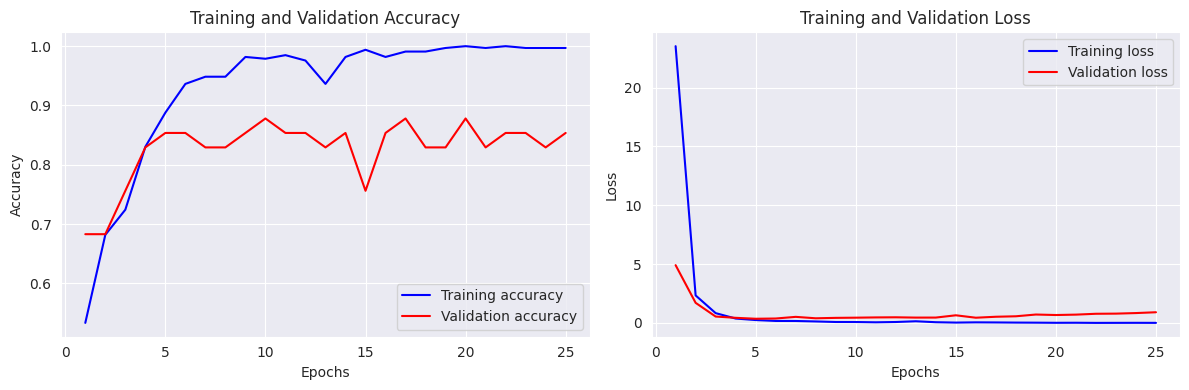

In [ ]:
# ==================================================
# 7. PLOT GRAFIK TRAINING
# ==================================================
def tr_plot(history_dict, option=0):
    """
    Menampilkan grafik training dari dictionary history.
    history_dict: dictionary yang berisi key 'accuracy', 'val_accuracy', 'loss', 'val_loss'
    option: 0 = accuracy & loss, 1 = accuracy only, 2 = loss only
    """
    epochs_range = range(1, len(history_dict['accuracy']) + 1)
    if option == 0 or option == 1:
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(epochs_range, history_dict['accuracy'], 'b-', label='Training accuracy')
        plt.plot(epochs_range, history_dict['val_accuracy'], 'r-', label='Validation accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
    if option == 0 or option == 2:
        if option == 0:
            plt.subplot(1,2,2)
        else:
            plt.figure(figsize=(6,4))
        plt.plot(epochs_range, history_dict['loss'], 'b-', label='Training loss')
        plt.plot(epochs_range, history_dict['val_loss'], 'r-', label='Validation loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
    plt.tight_layout()
    plt.show()

  # Load history
with open(history_path, 'rb') as f:
    history_dict = pickle.load(f)

# Panggil fungsi
tr_plot(history_dict, 0)

Training accuracy pada epoch terakhir (25): 0.9970
Validation accuracy pada epoch terakhir : 0.8537
Validation loss pada epoch terakhir  : 0.9064


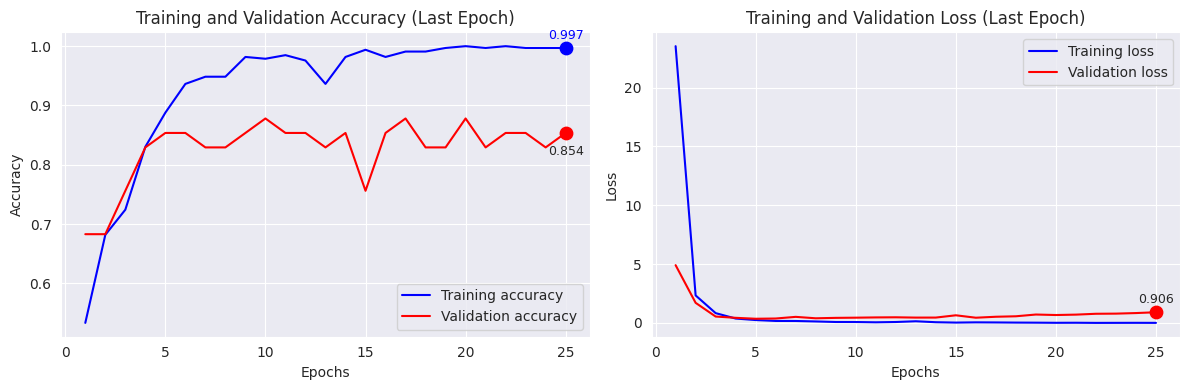

In [ ]:
def tr_plot(history_dict, option=0):
    """
    Menampilkan grafik training dengan anotasi pada epoch terakhir.
    option: 0 = accuracy & loss, 1 = accuracy only, 2 = loss only
    """
    epochs = range(1, len(history_dict['accuracy']) + 1)

    # ========== GRAFIK AKURASI ==========
    if option == 0 or option == 1:
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(epochs, history_dict['accuracy'], 'b-', label='Training accuracy')
        plt.plot(epochs, history_dict['val_accuracy'], 'r-', label='Validation accuracy')

        # Ambil nilai pada epoch terakhir
        last_epoch = len(history_dict['accuracy'])
        last_train_acc = history_dict['accuracy'][-1]
        last_val_acc = history_dict['val_accuracy'][-1]

        # Dot untuk validation accuracy (merah) dan training accuracy (biru) di epoch terakhir
        plt.scatter(last_epoch, last_val_acc, color='red', s=80, zorder=5)
        plt.scatter(last_epoch, last_train_acc, color='blue', s=80, zorder=5, marker='o')

        # Teks validation accuracy di BAWAH dot
        plt.text(last_epoch, last_val_acc - 0.02, f'{last_val_acc:.3f}',
                 ha='center', va='top', fontsize=9, family='Times New Roman')
        # Teks training accuracy di ATAS dot
        plt.text(last_epoch, last_train_acc + 0.01, f'{last_train_acc:.3f}',
                 ha='center', va='bottom', fontsize=9, family='Times New Roman', color='blue')

        plt.title('Training and Validation Accuracy (Last Epoch)')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        print(f"Training accuracy pada epoch terakhir ({last_epoch}): {last_train_acc:.4f}")
        print(f"Validation accuracy pada epoch terakhir : {last_val_acc:.4f}")

    # ========== GRAFIK LOSS ==========
    if option == 0 or option == 2:
        if option == 0:
            plt.subplot(1,2,2)
        else:
            plt.figure(figsize=(6,4))

        plt.plot(epochs, history_dict['loss'], 'b-', label='Training loss')
        plt.plot(epochs, history_dict['val_loss'], 'r-', label='Validation loss')

        last_epoch = len(history_dict['loss'])
        last_train_loss = history_dict['loss'][-1]
        last_val_loss = history_dict['val_loss'][-1]

        # Dot untuk validation loss (merah) di epoch terakhir
        plt.scatter(last_epoch, last_val_loss, color='red', s=80, zorder=5)
        # Teks validation loss di ATAS dot (offset +0.2)
        plt.text(last_epoch, last_val_loss + 0.5, f'{last_val_loss:.3f}',
                 ha='center', va='bottom', fontsize=9, family='Times New Roman')

        plt.title('Training and Validation Loss (Last Epoch)')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        print(f"Validation loss pada epoch terakhir  : {last_val_loss:.4f}")

    plt.tight_layout()
    plt.show()

tr_plot(history_dict, option=0)   # tampilkan accuracy dan loss

In [ ]:
# ==================================================
# 8. EVALUASI PADA TEST SET
# ==================================================
print("\nEvaluasi pada test set...")
acc = model.evaluate(test_gen, steps=test_steps, verbose=1)[1] * 100
print(f"Accuracy on test set: {acc:.2f} %")


Evaluasi pada test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 42s 42s/step - accuracy: 0.8293 - loss: 0.6638
Accuracy on test set: 82.93 %


1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step


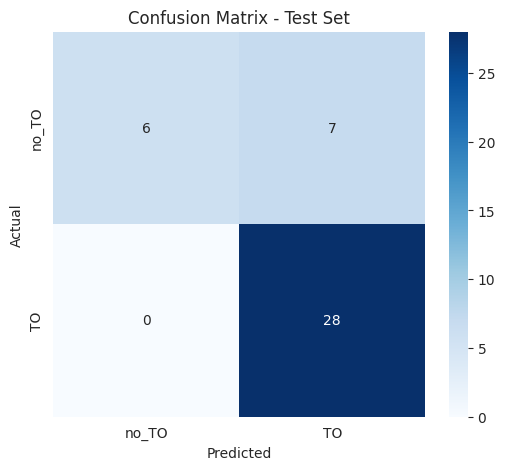


Classification Report:
----------------------
              precision    recall  f1-score   support

       no_TO       1.00      0.46      0.63        13
          TO       0.80      1.00      0.89        28

    accuracy                           0.83        41
   macro avg       0.90      0.73      0.76        41
weighted avg       0.86      0.83      0.81        41



In [ ]:
# ==================================================
# 9. PREDIKSI DAN CLASSIFICATION REPORT + CONFUSION MATRIX
# ==================================================
preds = model.predict(test_gen, steps=test_steps)
y_true = test_gen.labels          # no_TO=0, TO=1
y_pred = np.argmax(preds, axis=1)

kelas_tampilan = ['no_TO', 'TO']

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=kelas_tampilan, yticklabels=kelas_tampilan)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

print("\nClassification Report:\n----------------------")
print(classification_report(y_true, y_pred, target_names=kelas_tampilan))

In [ ]:
# ==================================================
# 10. INDIKASI OVERFITTING (menggunakan history yang sudah ada)
# ==================================================
final_train_acc = history_dict['accuracy'][-1]
final_val_acc = history_dict['val_accuracy'][-1]
print(f"Final training accuracy: {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")
print(f"Difference: {final_train_acc - final_val_acc:.4f}")

if (final_train_acc - final_val_acc) > 0.05:
    print("Indikasi overfitting (selisih > 5%)")
else:
    print("Tidak ada indikasi overfitting yang serius")

Final training accuracy: 0.9970
Final validation accuracy: 0.8537
Difference: 0.1433
Indikasi overfitting (selisih > 5%)


In [ ]:
# Cek akurasi validasi terbaik sepanjang training
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
train_acc_at_best = history.history['accuracy'][best_epoch-1]
print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")
print(f"Training accuracy at that epoch: {train_acc_at_best:.4f}")
print(f"Difference: {train_acc_at_best - best_val_acc:.4f}")

Best validation accuracy: 0.9512 at epoch 23
Training accuracy at that epoch: 0.9939
Difference: 0.0427


In [ ]:
def print_info( test_gen, preds, print_code, save_dir, subject ):
    class_dict=test_gen.class_indices
    labels= test_gen.labels
    file_names= test_gen.filenames
    error_list=[]
    true_class=[]
    pred_class=[]
    prob_list=[]
    new_dict={}
    error_indices=[]
    y_pred=[]
    for key,value in class_dict.items():
        new_dict[value]=key             # dictionary {integer of class number: string of class name}
    # store new_dict as a text fine in the save_dir
    classes=list(new_dict.values())     # list of string of class names
    dict_as_text=str(new_dict)
    dict_name= subject + '-' +str(len(classes)) +'.txt'
    dict_path=os.path.join(save_dir,dict_name)
    with open(dict_path, 'w') as x_file:
        x_file.write(dict_as_text)
    errors=0
    for i, p in enumerate(preds):
        pred_index=np.argmax(p)
        true_index=labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            error_list.append(file_names[i])
            true_class.append(new_dict[true_index])
            pred_class.append(new_dict[pred_index])
            prob_list.append(p[pred_index])
            error_indices.append(true_index)
            errors=errors + 1
        y_pred.append(pred_index)
    if print_code !=0:
        if errors>0:
            if print_code>errors:
                r=errors
            else:
                r=print_code
            msg='{0:^28s}{1:^28s}{2:^28s}{3:^16s}'.format('Filename', 'Predicted Class' , 'True Class', 'Probability')
            print_in_color(msg, (0,255,0),(55,65,80))
            for i in range(r):
                split1=os.path.split(error_list[i])
                split2=os.path.split(split1[0])
                fname=split2[1] + '/' + split1[1]
                msg='{0:^28s}{1:^28s}{2:^28s}{3:4s}{4:^6.4f}'.format(fname, pred_class[i],true_class[i], ' ', prob_list[i])
                print_in_color(msg, (255,255,255), (55,65,60))
                #print(error_list[i]  , pred_class[i], true_class[i], prob_list[i])
        else:
            msg='With accuracy of 100 % there are no errors to print'
            print_in_color(msg, (0,255,0),(55,65,80))
    if errors>0:
        plot_bar=[]
        plot_class=[]
        for  key, value in new_dict.items():
            count=error_indices.count(key)
            if count!=0:
                plot_bar.append(count) # list containg how many times a class c had an error
                plot_class.append(value)   # stores the class
        fig=plt.figure()
        fig.set_figheight(len(plot_class)/3)
        fig.set_figwidth(10)
        plt.style.use('fivethirtyeight')
        for i in range(0, len(plot_class)):
            c=plot_class[i]
            x=plot_bar[i]
            plt.barh(c, x, )
            plt.title( ' Errors by Class on Test Set')
    y_true= np.array(labels)
    y_pred=np.array(y_pred)
    if len(classes)<= 30:
        # create a confusion matrix
        cm = confusion_matrix(y_true, y_pred )
        length=len(classes)
        if length<8:
            fig_width=8
            fig_height=8
        else:
            fig_width= int(length * .5)
            fig_height= int(length * .5)
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(length)+.5, classes, rotation= 90)
        plt.yticks(np.arange(length)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes)
    print("Classification Report:\n----------------------\n", clr)

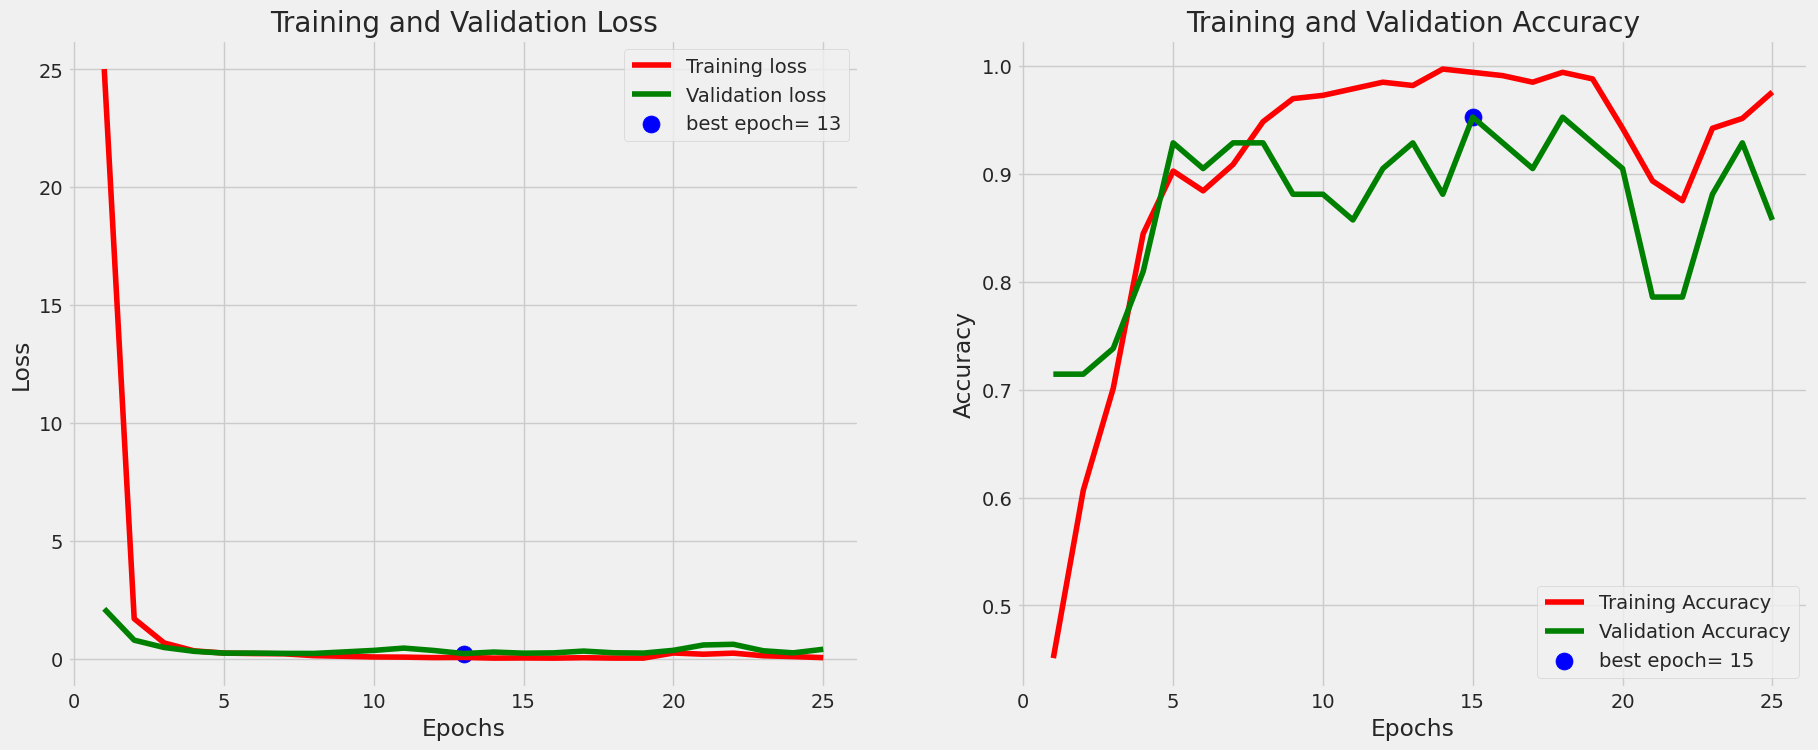

1/1 ━━━━━━━━━━━━━━━━━━━━ 37s 37s/step - accuracy: 0.8780 - loss: 0.4562
accuracy on the test set is 87.80 %



In [ ]:
tr_plot(history,0)
save_dir=r'./'
subject='pest'
acc=model.evaluate( test_gen, batch_size=test_batch_size, verbose=1, steps=test_steps, return_dict=False)[1]*100
msg=f'accuracy on the test set is {acc:5.2f} %'
print_in_color(msg, (0,255,0),(55,65,80))

1/1 ━━━━━━━━━━━━━━━━━━━━ 38s 38s/step


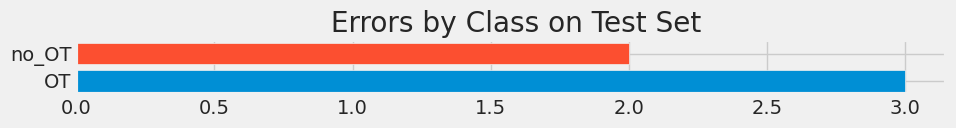

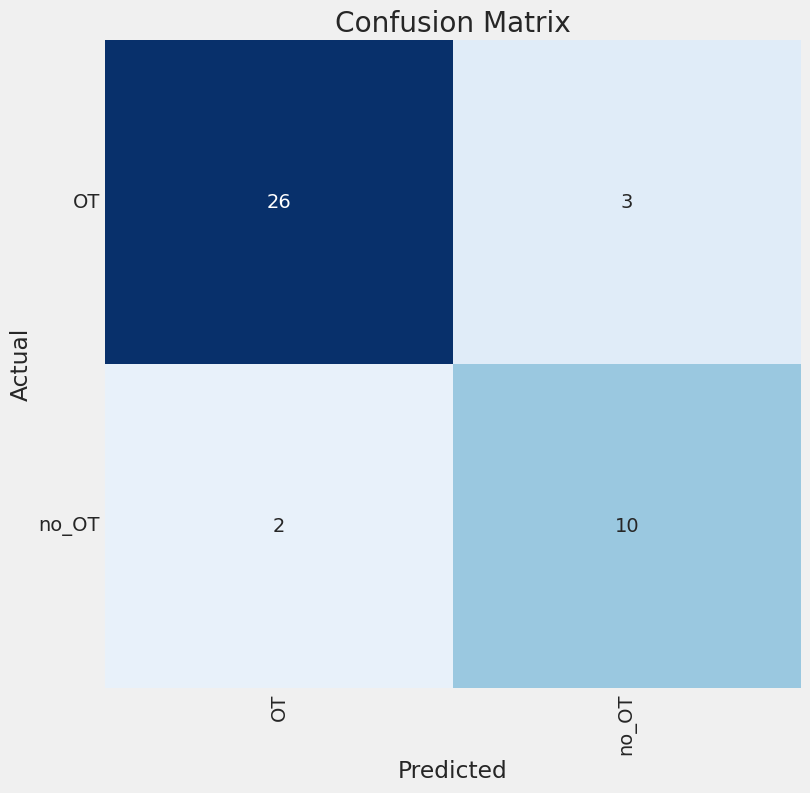

Classification Report:
----------------------
               precision    recall  f1-score   support

          OT       0.93      0.90      0.91        29
       no_OT       0.77      0.83      0.80        12

    accuracy                           0.88        41
   macro avg       0.85      0.86      0.86        41
weighted avg       0.88      0.88      0.88        41



In [ ]:
print_code=0
preds=model.predict(test_gen)
print_info( test_gen, preds, print_code, save_dir, subject )

In [ ]:
# Prediksi gambar tunggal
# img_path = '/content/656.jpg'

from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(image_path, model, classes):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize and add batch dimension

    predictions = model.predict(img_array)
    confidence = np.max(predictions)
    predicted_class_index = np.argmax(predictions)
    predicted_class = classes[predicted_class_index]

    return predicted_class, confidence, predictions

uploaded = files.upload()
uploaded_filename = list(uploaded.keys())[0]  # Ambil nama file pertama
image_path = f'/content/{uploaded_filename}'

predicted_class, confidence, _ = predict_image(image_path, model, classes)
print(f"Hasil prediksi: {predicted_class} ({confidence:.2%})")

Saving 33.png to 33.png


NameError: name 'predict_image' is not defined